In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
PROJECT_PATH = r"D:\saas360"
CLEANED_PATH = PROJECT_PATH + r"\cleaned"

accounts = pd.read_csv(
    CLEANED_PATH + r"\accounts_clean.csv"
)

subscriptions = pd.read_csv(
    CLEANED_PATH + r"\subscriptions_clean.csv"
)

feature_usage = pd.read_csv(
    CLEANED_PATH + r"\feature_usage_clean.csv"
)

support_tickets = pd.read_csv(
    CLEANED_PATH + r"\support_tickets_clean.csv"
)

churn_events = pd.read_csv(
    CLEANED_PATH + r"\churn_events_clean.csv"
)

print("All cleaned datasets loaded successfully.")

All cleaned datasets loaded successfully.


In [3]:
accounts["signup_date"] = pd.to_datetime(
    accounts["signup_date"]
)

subscriptions["start_date"] = pd.to_datetime(
    subscriptions["start_date"]
)

subscriptions["end_date"] = pd.to_datetime(
    subscriptions["end_date"]
)

feature_usage["usage_date"] = pd.to_datetime(
    feature_usage["usage_date"]
)

support_tickets["submitted_at"] = pd.to_datetime(
    support_tickets["submitted_at"]
)

support_tickets["closed_at"] = pd.to_datetime(
    support_tickets["closed_at"]
)

churn_events["churn_date"] = pd.to_datetime(
    churn_events["churn_date"]
)

print("Date columns converted.")

Date columns converted.


In [4]:
print("Accounts:", accounts.shape)
print("Subscriptions:", subscriptions.shape)
print("Feature Usage:", feature_usage.shape)
print("Support Tickets:", support_tickets.shape)
print("Churn Events:", churn_events.shape)

Accounts: (500, 10)
Subscriptions: (5000, 15)
Feature Usage: (25000, 9)
Support Tickets: (2000, 10)
Churn Events: (600, 9)


In [5]:
print("Total Accounts:", accounts["account_id"].nunique())

Total Accounts: 500


In [6]:
print("\nAccounts by Industry:")
print(accounts["industry"].value_counts())


Accounts by Industry:
industry
DevTools         113
FinTech          112
Cybersecurity    100
HealthTech        96
EdTech            79
Name: count, dtype: int64


In [7]:
print("\nTrial Status:")
print(accounts["is_trial"].value_counts())


Trial Status:
is_trial
False    403
True      97
Name: count, dtype: int64


In [8]:
print("\nAccounts by Plan:")
print(accounts["plan_tier"].value_counts())


Accounts by Plan:
plan_tier
Pro           178
Basic         168
Enterprise    154
Name: count, dtype: int64


In [9]:
print("\nAccounts by Referral Source:")
print(accounts["referral_source"].value_counts())


Accounts by Referral Source:
referral_source
organic    114
other      103
ads         98
event       96
partner     89
Name: count, dtype: int64


In [10]:
print("Churned Accounts:")
print(accounts["churn_flag"].value_counts())

Churned Accounts:
churn_flag
False    390
True     110
Name: count, dtype: int64


In [11]:
churn_rate = accounts["churn_flag"].mean() * 100

print(f"Overall Account Churn Rate: {churn_rate:.2f}%")

Overall Account Churn Rate: 22.00%


In [12]:
churn_by_plan = (
    accounts
    .groupby("plan_tier")
    .agg(
        total_accounts=("account_id", "nunique"),
        churned_accounts=("churn_flag", "sum")
    )
)

churn_by_plan["churn_rate"] = (
    churn_by_plan["churned_accounts"]
    / churn_by_plan["total_accounts"]
    * 100
)

churn_by_plan = churn_by_plan.sort_values(
    "churn_rate",
    ascending=False
)

churn_by_plan

,total_accounts,churned_accounts,churn_rate
plan_tier,,,
Enterprise,154,34,22.077922
Basic,168,37,22.023810
Pro,178,39,21.910112


In [13]:
churn_by_industry = (
    accounts
    .groupby("industry")
    .agg(
        total_accounts=("account_id", "nunique"),
        churned_accounts=("churn_flag", "sum")
    )
)

churn_by_industry["churn_rate"] = (
    churn_by_industry["churned_accounts"]
    / churn_by_industry["total_accounts"]
    * 100
)

churn_by_industry = churn_by_industry.sort_values(
    "churn_rate",
    ascending=False
)

churn_by_industry

,total_accounts,churned_accounts,churn_rate
industry,,,
DevTools,113,35,30.973451
FinTech,112,25,22.321429
HealthTech,96,21,21.875000
EdTech,79,13,16.455696
Cybersecurity,100,16,16.000000


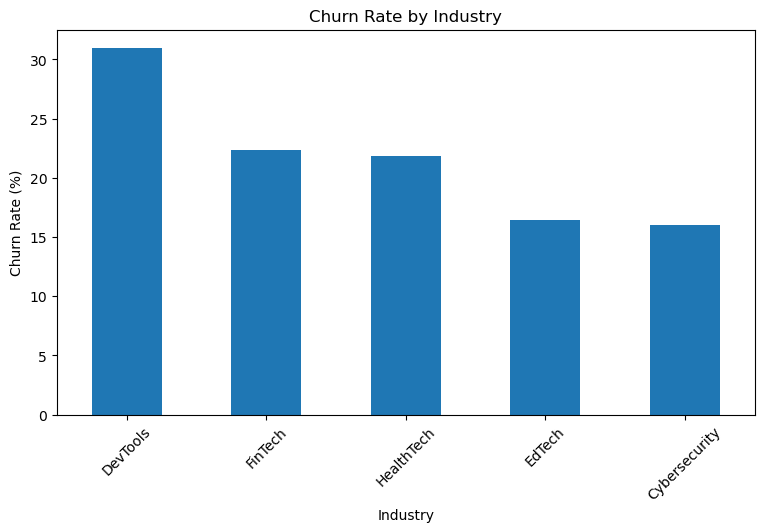

In [14]:
plt.figure(figsize=(9, 5))

churn_by_industry["churn_rate"].plot(
    kind="bar"
)

plt.title("Churn Rate by Industry")
plt.xlabel("Industry")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [15]:
churn_by_referral = (
    accounts
    .groupby("referral_source")
    .agg(
        total_accounts=("account_id", "nunique"),
        churned_accounts=("churn_flag", "sum")
    )
)

churn_by_referral["churn_rate"] = (
    churn_by_referral["churned_accounts"]
    / churn_by_referral["total_accounts"]
    * 100
)

churn_by_referral = churn_by_referral.sort_values(
    "churn_rate",
    ascending=False
)

churn_by_referral

,total_accounts,churned_accounts,churn_rate
referral_source,,,
event,96,29,30.208333
other,103,25,24.271845
ads,98,23,23.469388
organic,114,20,17.543860
partner,89,13,14.606742


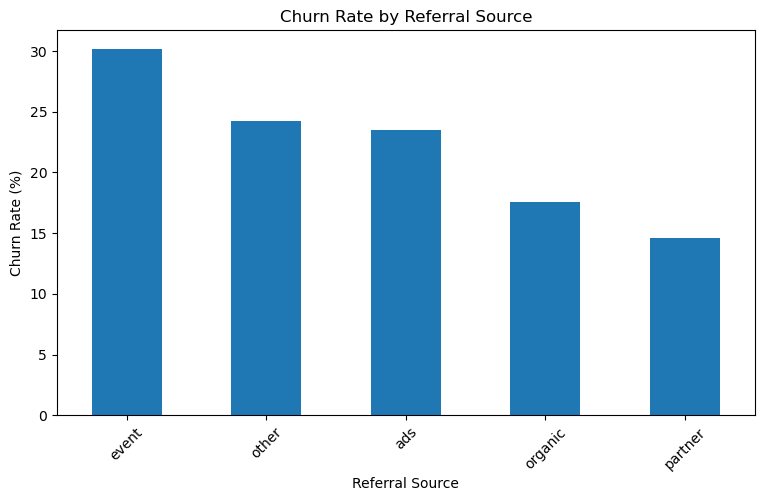

In [16]:
plt.figure(figsize=(9, 5))

churn_by_referral["churn_rate"].plot(
    kind="bar"
)

plt.title("Churn Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [17]:
subscriptions["subscription_status"].value_counts()

subscription_status
Active    4514
Ended      486
Name: count, dtype: int64

In [18]:
active_subscriptions = subscriptions[
    subscriptions["subscription_status"] == "Active"
]

print(
    "Active subscriptions:",
    active_subscriptions["subscription_id"].nunique()
)

Active subscriptions: 4514


In [19]:
current_mrr = active_subscriptions["mrr_amount"].sum()

print(f"Current MRR: ${current_mrr:,.2f}")

Current MRR: $10,159,608.00


In [20]:
current_arr = active_subscriptions["arr_amount"].sum()

print(f"Current ARR: ${current_arr:,.2f}")

Current ARR: $121,915,296.00


In [21]:
print(
    "MRR × 12:",
    round(current_mrr * 12, 2)
)

print(
    "ARR:",
    round(current_arr, 2)
)

MRR × 12: 121915296
ARR: 121915296


In [22]:
# Revenue overview

active_subscriptions = subscriptions[
    subscriptions["subscription_status"] == "Active"
]

current_mrr = active_subscriptions["mrr_amount"].sum()
current_arr = active_subscriptions["arr_amount"].sum()

mrr_by_plan = (
    active_subscriptions
    .groupby("plan_tier")
    .agg(
        subscriptions=("subscription_id", "nunique"),
        mrr=("mrr_amount", "sum"),
        avg_mrr=("mrr_amount", "mean")
    )
    .sort_values("mrr", ascending=False)
)

print(f"Active subscriptions: {active_subscriptions['subscription_id'].nunique():,}")
print(f"Current MRR: ${current_mrr:,.2f}")
print(f"Current ARR: ${current_arr:,.2f}")

print("\nMRR by Plan:")
display(mrr_by_plan)

Active subscriptions: 4,514
Current MRR: $10,159,608.00
Current ARR: $121,915,296.00

MRR by Plan:


,subscriptions,mrr,avg_mrr
plan_tier,,,
Enterprise,1551,7546876,4865.813024
Pro,1513,1924818,1272.186385
Basic,1450,687914,474.423448
